EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
df = pd.read_csv('data/train.csv')

Рассмотрим SalePrice, из графика будет видно что присутствует правосторонняя ассиметрия - график сильно растягивается вправо. Справа - дома с очень высокой ценой, и если оставить все как есть, то модель может начать ошибаться на них, они будут для нее аномалиями.

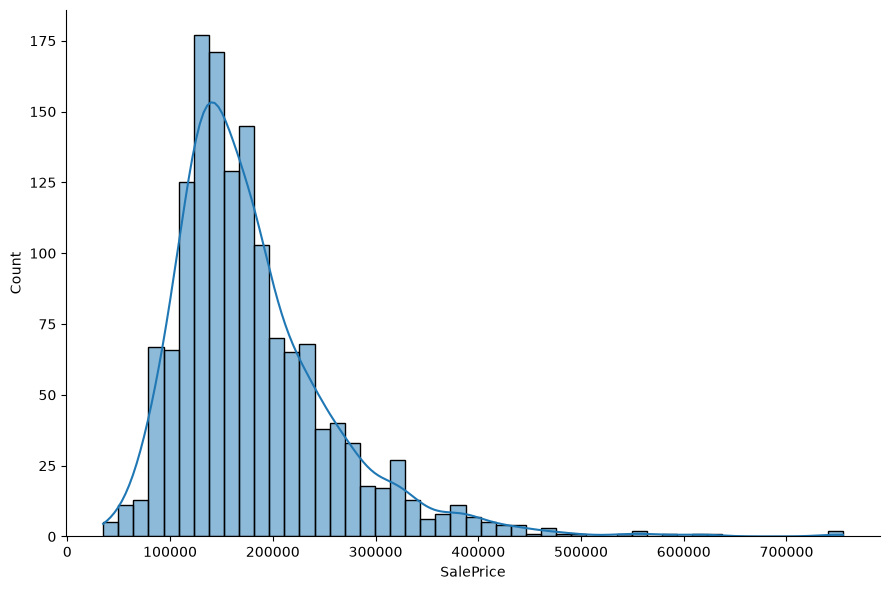

In [3]:
sns.displot(train['SalePrice'], kde=True, height=6, aspect=1.5)

Регрессионные модели лучше работают с нормальным распределением - симметрией. Поэтому можно применить логарифмирование для этой фичи (она же является целевой переменной).

In [4]:
train['SalePriceLog'] = np.log1p(train['SalePrice']) # создаем нужный нам логарифмированный таргет для обучения
train = train.drop(columns=['SalePrice'])

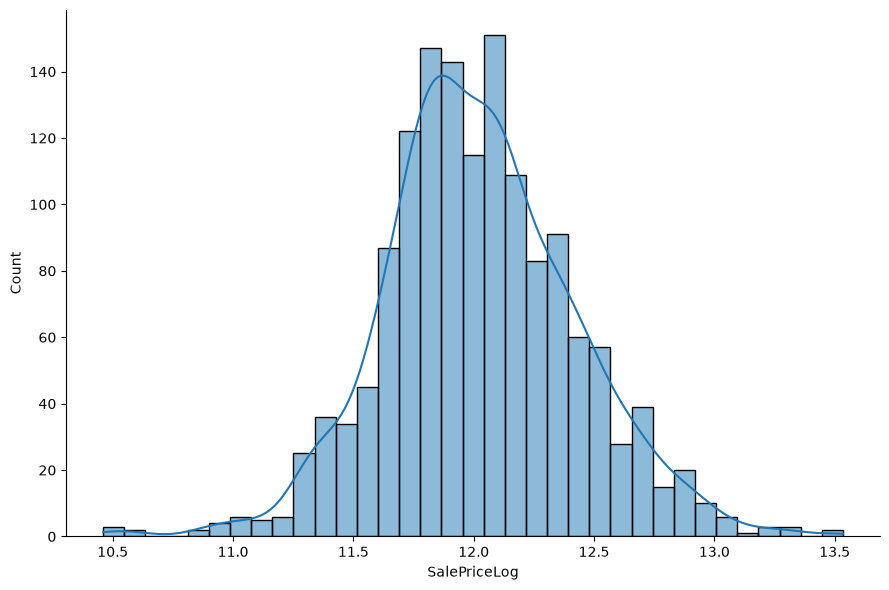

In [5]:
sns.displot(train['SalePriceLog'], kde=True, height=6, aspect=1.5)

Глянем сколько фичей, пропусков, типы данных

In [6]:
print(train.shape)
print(train.dtypes.value_counts())
print(train.isnull().sum().sort_values(ascending=False).head(22))

(1460, 81)
str        43
int64      34
float64     4
Name: count, dtype: int64
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
BldgType           0
Neighborhood       0
dtype: int64


<span style="font-size: 13px;">
PoolQC: NA	No Pool

MiscFeature (Miscellaneous feature not covered in other categories): NA	None

Alley (Type of alley access to property): NA No alley access

Fence (Fence quality): NA No Fence

MasVnrType (Masonry veneer type): None None

FireplaceQu (Fireplace quality): NA	No Fireplace

LotFrontage: Linear feet of street connected to property (no info about NA)

GarageType (Garage location): NA No Garage

GarageQual: NA No Garage

GarageFinish: NA No Garage

GarageYrBlt: Year garage was built (no info about NA)

BsmtQual (Evaluates the height of the basement): NA No Basement

BsmtExposure: NA No Garage

BsmtFinType1: NA No Garage

BsmtFinType2: NA No Garage

BsmtCond: NA No Garage

MasVnrType: None None

Electrical: no info about NA
</span>

<span style="font-size: 14px;">
Для дальнейшего анализа пропусков разделим вышеописанные фичи на 3 Группы.

Группа 1. NaN для категориальной фичи, означающая что объекта нет [(no fireplace, no pool, no garage, etc.), (PoolQC, MiscFeature, Alley, Fence, FireplaceQu, GarageType, GarageQual, GarageFinish, BsmtQual, BsmtExposure, BsmtFinType1, BsmtFinType2, BsmtCond)]

Группа 2. NaN для числовой фичи, означающая что объекта нет [(no garage year built, etc.) (GarageYrBlt, MasVnrArea)]

Группа 3. Реальные пропуски (LotFrontage, Electrical).
</span>

In [7]:
# == Missing Values ==

# -- Group 1 --
cat_none_cols = [ 
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageQual', 'GarageCond', 'GarageFinish', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'BsmtCond'
]
for col in cat_none_cols:
    train[col] = train[col].fillna('None')
    test[col] = test[col].fillna('None')

# -- Group 2 --
num_zero_cols = [
    'GarageYrBlt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea'
]
for col in num_zero_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# -- Group 3 --
lot_median_by_neighborhood = train.groupby('Neighborhood')['LotFrontage'].median()
train['LotFrontage'] = train['LotFrontage'].fillna(
    train['Neighborhood'].map(lot_median_by_neighborhood)
)
test['LotFrontage'] = test['LotFrontage'].fillna(
    test['Neighborhood'].map(lot_median_by_neighborhood)
)

train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])
train['MasVnrType'] = train['MasVnrType'].fillna(train['MasVnrType'].mode()[0])
test['MasVnrType'] = test['MasVnrType'].fillna(train['MasVnrType'].mode()[0])

test_mode_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd', 'KitchenQual', 'Functional', 'SaleType']
for col in test_mode_cols:
    test[col]= test[col].fillna(train[col].mode()[0])

print("Train remaining NaN:", train.isnull().sum().sum())
print("Test remaining NaN:", test.isnull().sum().sum())

Train remaining NaN: 0
Test remaining NaN: 0
